In [ ]:
import torch
from torch import nn # nn contails all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

torch.__version__

'2.10.0+cpu'

# 1. Data preparatin and loading

In [ ]:
weights = 0.7
bias = 0.3

# create data

start = 0
end = 1
step = 0.02

X = torch.arange(start,end,step).unsqueeze(dim=1)

y = weight * X + bias

X[:10] , y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [ ]:
len(X), len(y)

(50, 50)

## Spliting data into training and test sets (one of the most important concept in ML in general)

In [ ]:
train_split = int(0.8 * len(X))
train_split

40

In [ ]:
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test, = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

data visualization

In [ ]:
def plot_predictions(train_data = X_train , train_labels= y_train,
                     test_data = X_test, test_labels= y_test,
                     predictions= None):
  plt.figure(figsize = (10,7))

  plt.scatter(train_data, train_labels, c = "b", s=4, label="Training data")

  plt.scatter(test_data, test_labels, c = "g", s= 4, label = "Testing data")

  if predictions is not None:

    plt.scatter(test_data, predictions, c = "r", s=4, label= "Predctions")

  plt.legend(prop={"size" : 14})

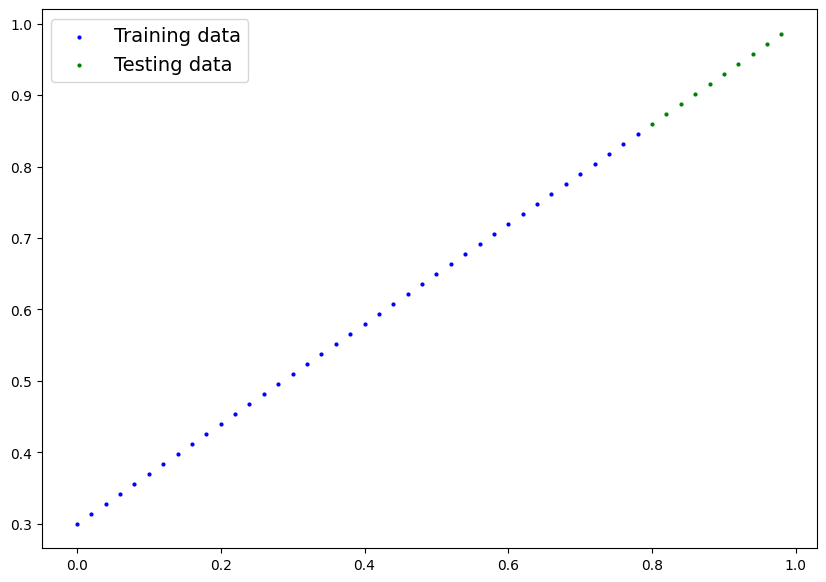

In [ ]:
plot_predictions()

 #@ 2.building model

In [ ]:
# create linear regression model class
from torch import nn

class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.rand(1,
                                          requires_grad=True,
                                          dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1,
                                         requires_grad=True,
                                         dtype=torch.float))

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.weights * x + self.bias

In [ ]:
### checking the contents of PyTorch model


# creatre random seed
torch.manual_seed(42)

#Create an instance of the model ( this is a subclass of nn.Module)

model_0 = LinearRegressionModel()

list(model_0.parameters())

[Parameter containing:
 tensor([0.8823], requires_grad=True),
 Parameter containing:
 tensor([-0.6382], requires_grad=True)]

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.8823])), ('bias', tensor([-0.6382]))])

In [ ]:
weights, bias

(0.7, 0.3)

Making prediction using torch.inference_mode()


In [ ]:
X_test, y_test

In [ ]:
with torch.inference_mode():
  y_preds = model_0(X_test)

y_preds

tensor([[0.0677],
        [0.0853],
        [0.1030],
        [0.1206],
        [0.1382],
        [0.1559],
        [0.1735],
        [0.1912],
        [0.2088],
        [0.2265]])

In [ ]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

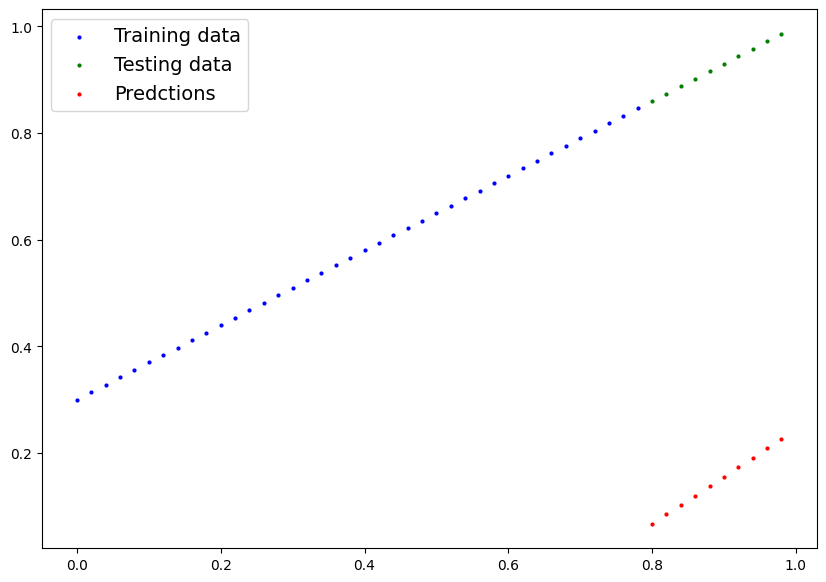

In [ ]:
plot_predictions(predictions=y_preds)

to read about torch.inference_mode()